## ThinkDSP

This notebook contains code examples from Chapter 3: Non-periodic signals

Copyright 2015 Allen Downey

License: [Creative Commons Attribution 4.0 International](http://creativecommons.org/licenses/by/4.0/)

In [49]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)

download("https://github.com/AllenDowney/ThinkDSP/raw/master/thinkdsp/thinkdsp.py")


In [50]:
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import decorate

### Chirp

Make a linear chirp from A3 to A5.

In [51]:
from thinkdsp import Chirp

signal = Chirp(start=220, end=880)
wave1 = signal.make_wave(duration=2)
wave1.make_audio()

Here's what the waveform looks like near the beginning.

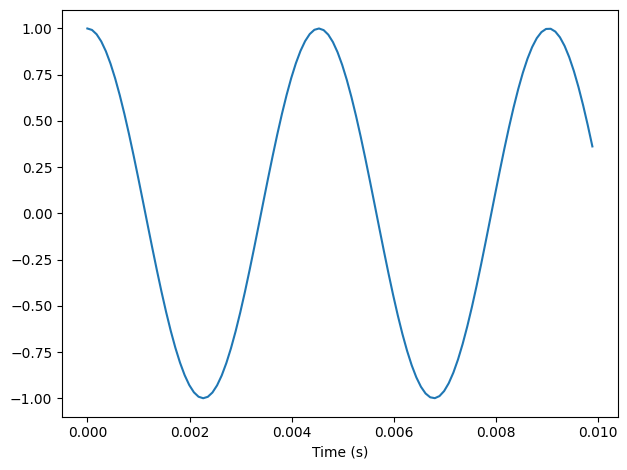

In [52]:
wave1.segment(start=0, duration=0.01).plot()
decorate(xlabel='Time (s)')

And near the end.

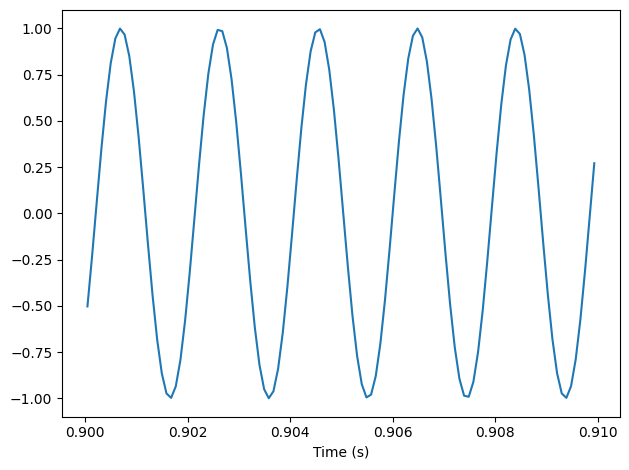

In [53]:
wave1.segment(start=0.9, duration=0.01).plot()
decorate(xlabel='Time (s)')

Here's an exponential chirp with the same frequency range and duration.

In [54]:
from thinkdsp import ExpoChirp

signal = ExpoChirp(start=220, end=880)
wave2 = signal.make_wave(duration=2)
wave2.make_audio()

## Leakage

Spectral leakage is when some of the energy at one frequency appears at another frequency (usually nearby).

Let's look at the effect of leakage on a sine signal (which only contains one frequency component).

In [55]:
from thinkdsp import SinSignal

signal = SinSignal(freq=440)

If the duration is an integer multiple of the period, the beginning and end of the segment line up, and we get minimal leakage.

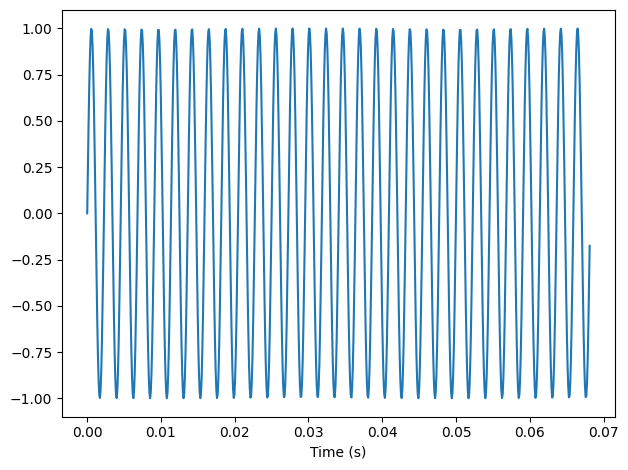

In [56]:
duration = signal.period * 30
wave = signal.make_wave(duration)
wave.plot()
decorate(xlabel='Time (s)')

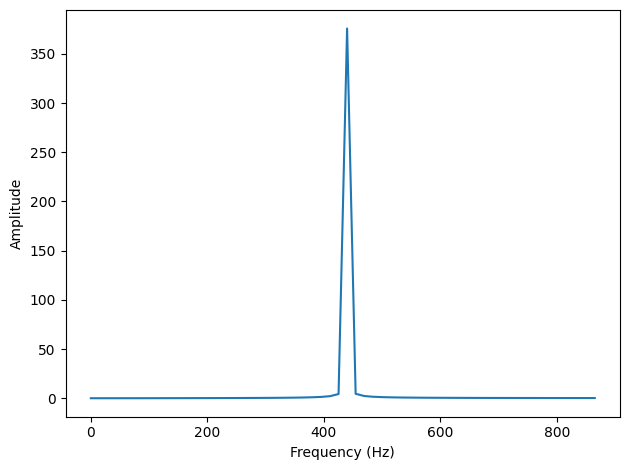

In [57]:
spectrum = wave.make_spectrum()
spectrum.plot(high=880)
decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')

If the duration is not a multiple of a period, the leakage is pretty bad.

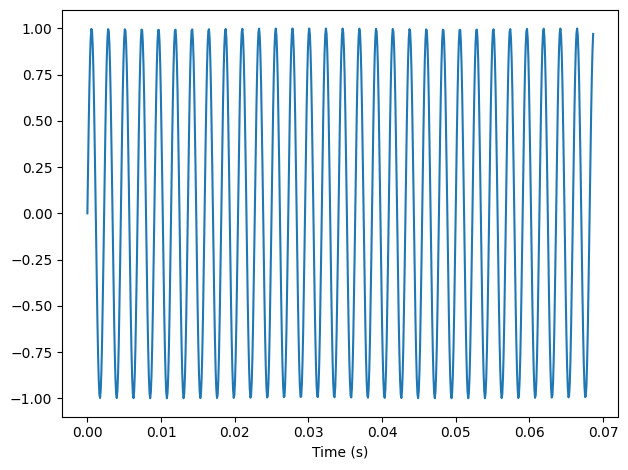

In [58]:
duration = signal.period * 30.25
wave = signal.make_wave(duration)
wave.plot()
decorate(xlabel='Time (s)')

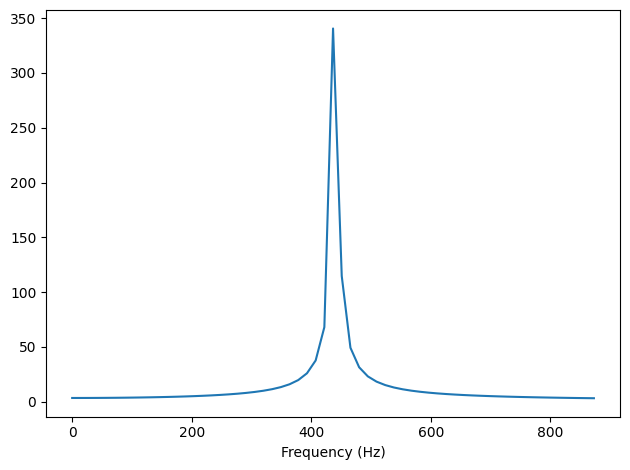

In [59]:
spectrum = wave.make_spectrum()
spectrum.plot(high=880)
decorate(xlabel='Frequency (Hz)')

Windowing helps (but notice that it reduces the total energy).

758
758
758
758
758
758


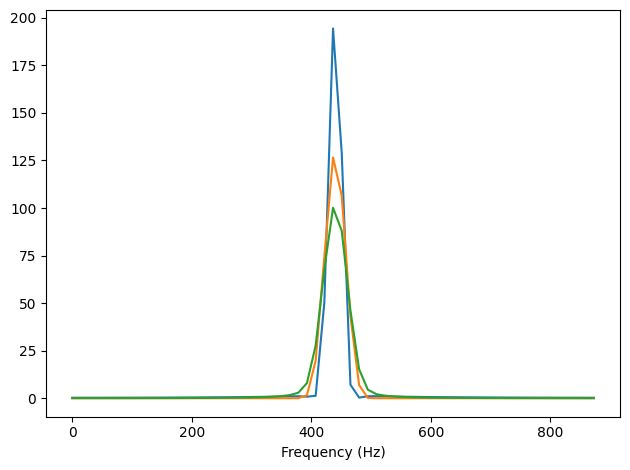

In [60]:
for window_func in [np.hamming, np.blackman, np.bartlett]:
    print(len(wave))
    print(len(wave.ys))
    # wave.window(window_func(len(wave)))
    wave.ys *= window_func(len(wave))
    spectrum = wave.make_spectrum()
    spectrum.plot(high=880)
decorate(xlabel='Frequency (Hz)')

## Spectrogram

If you blindly compute the DFT of a non-periodic segment, you get "motion blur".

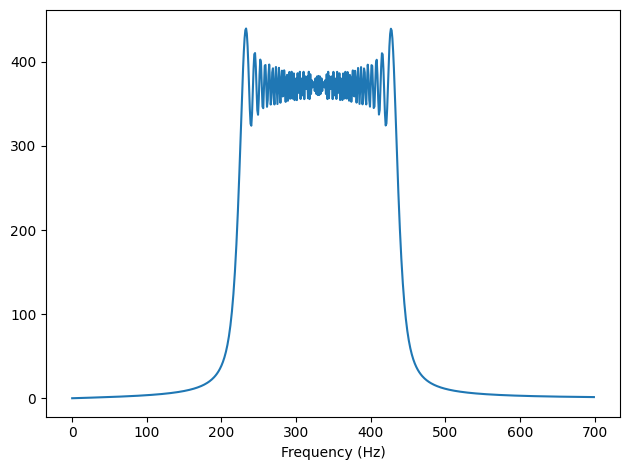

In [61]:
signal = Chirp(start=220, end=440)
wave = signal.make_wave(duration=1)
spectrum = wave.make_spectrum()
spectrum.plot(high=700)
decorate(xlabel='Frequency (Hz)')

A spectrogram is a visualization of a short-time DFT that lets you see how the spectrum varies over time.

In [62]:
def plot_spectrogram(wave, seg_length):
    """
    """
    spectrogram = wave.make_spectrogram(seg_length)
    print('Time resolution (s)', spectrogram.time_res)
    print('Frequency resolution (Hz)', spectrogram.freq_res)
    spectrogram.plot(high=700)
    decorate(xlabel='Time(s)', ylabel='Frequency (Hz)')

Time resolution (s) 0.046439909297052155
Frequency resolution (Hz) 21.533203125


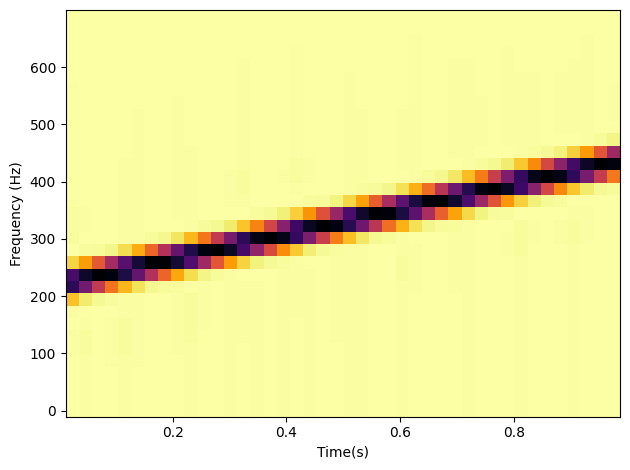

In [63]:
signal = Chirp(start=220, end=440)
wave = signal.make_wave(duration=1, framerate=11025)
plot_spectrogram(wave, 512)

If you increase the segment length, you get better frequency resolution, worse time resolution.

Time resolution (s) 0.09287981859410431
Frequency resolution (Hz) 10.7666015625


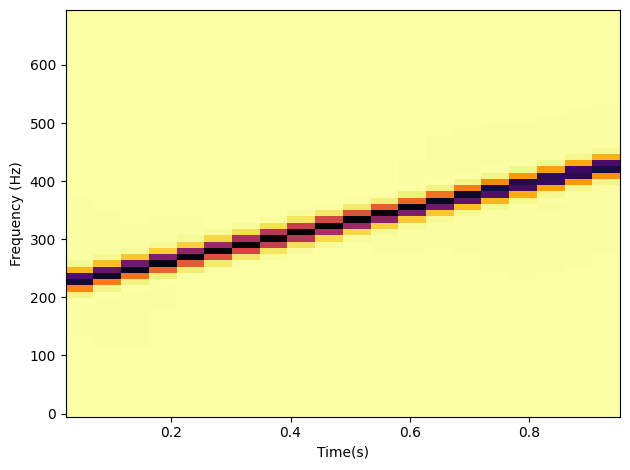

In [64]:
plot_spectrogram(wave, 1024)

If you decrease the segment length, you get better time resolution, worse frequency resolution.

Time resolution (s) 0.023219954648526078
Frequency resolution (Hz) 43.06640625


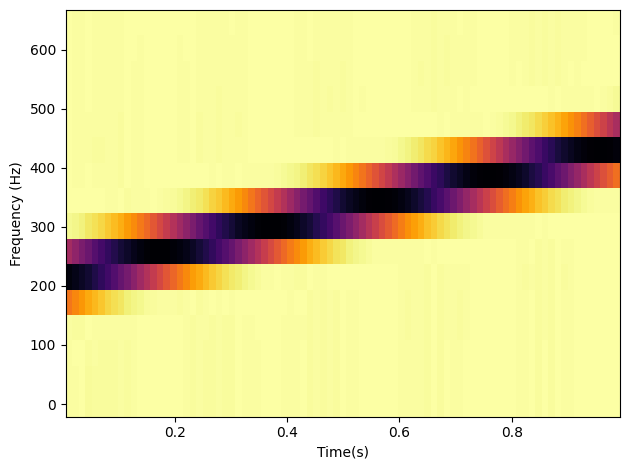

In [65]:
plot_spectrogram(wave, 256)

In [66]:
from ipywidgets import interact, interactive, fixed
import ipywidgets as widgets

slider = widgets.IntSlider(min=128, max=4096, value=100, step=128)
interact(plot_spectrogram, wave=fixed(wave), seg_length=slider);

interactive(children=(IntSlider(value=128, description='seg_length', max=4096, min=128, step=128), Output()), …

## Spectrum of a chirp

The following interaction lets you customize the Eye of Sauron as you vary the start and end frequency of the chirp.

In [67]:
def eye_of_sauron(start, end):
    """Plots the spectrum of a chirp.

    start: initial frequency
    end: final frequency
    """
    signal =  Chirp(start=start, end=end)
    wave = signal.make_wave(duration=0.5)
    spectrum = wave.make_spectrum()

    spectrum.plot(high=1200)
    decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')

In [68]:
slider1 = widgets.FloatSlider(min=100, max=1000, value=100, step=50)
slider2 = widgets.FloatSlider(min=100, max=1000, value=200, step=50)
interact(eye_of_sauron, start=slider1, end=slider2);

interactive(children=(FloatSlider(value=100.0, description='start', max=1000.0, min=100.0, step=50.0), FloatSl…

#3.2

In [113]:
from thinkdsp import SawtoothSignal, Chirp, PI2, normalize, unbias

class SawtoothChirp(Chirp):
    # returns a bunch of ys
    def evaluate(self, ts):

        # frequencies that lienarly increase
        freqs = np.linspace(self.start, self.end, len(ts))

        # ok an then at each of those frequencies you want the sawtooth to
        # perform and youw ant to find the fractional part of the cycle they are there


        #the question then is within that frequency interval how much time passe
        # and therefore how m

        dts = np.diff(ts, prepend=0)
        dphis = PI2 * freqs * dts
        # how many radians were consumed during that time

        # frequency already factors in phases inclues the radian position of the cos wave
        # at all of these times just want the y value

        phases = np.cumsum(dphis)

        # get the cycles by converting from radiants to cycle cycle is always 2pi
        cycles = phases / PI2
        frac, _ = np.modf(cycles)
        ys = normalize(unbias(frac), self.amp)

        return ys

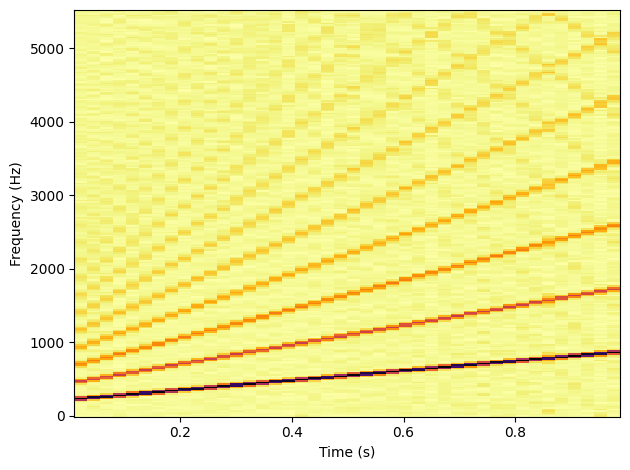

In [114]:
schirp = SawtoothChirp(220, 880)
wave = schirp.make_wave(duration=1)
specto = wave.make_spectrogram(512)
specto.plot()
decorate(xlabel='Time (s)', ylabel='Frequency (Hz)')

See aliasing in the fact that at the beginning frequency many harmonics are underneath the nyquist which is why you see more colored cells / the ccells are closer together. Fans out because the fundamental chagnes over time and then aliasing becomes a bigger issue. The rising bands are just the nromal harmonics, the downward folding the cause of aliasing, hitting a peak at the nyquist. You see this because once a smaller freuqnecy hits the nyquist peak, you will not see. aband higher than that the bands you se must be lower.

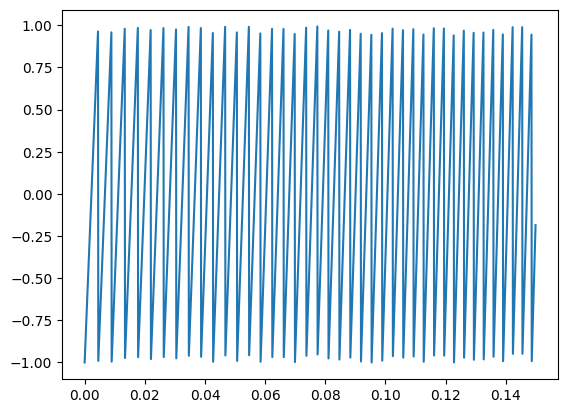

In [115]:
segment = wave.segment(start=0, duration=0.15)
segment.plot()

In [116]:
wave.make_audio()

I see the affect

#3.3

Make a sawotooth chirp that sweeps form 2500 to 300Hz, then use it to make a wave with duration 1s and framerate 20 kHz. raw a skethch of waht you thinkm the psectrum will lok like. Then plot the spectrum ansee if you got it right.

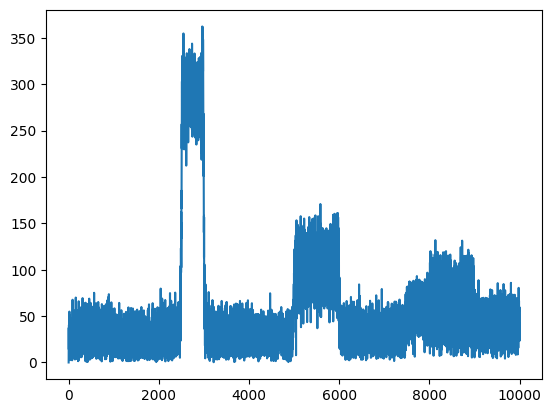

In [72]:
sc = SawtoothChirp(2500, 3000)
wave = sc.make_wave(duration=1, framerate=20000)
spectrum = wave.make_spectrum()
spectrum.plot()

Expect eye of sauron between 2500 and 3000 hz because there is no time axis in specturm analaysis just looks at the proportional contribution of each frequency. Spends equal amount of time at each frequency between 2500 to 3000 so you would expect the amplitude to be more or less flat between those frequencies. dont forget that the harmonics will alsoi show up in spectrum

#3.4

Glissando is a note that slides from one pitch to another. Find or make a recording of a glissando and plot a spectogram of the first few seconds.

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --ena

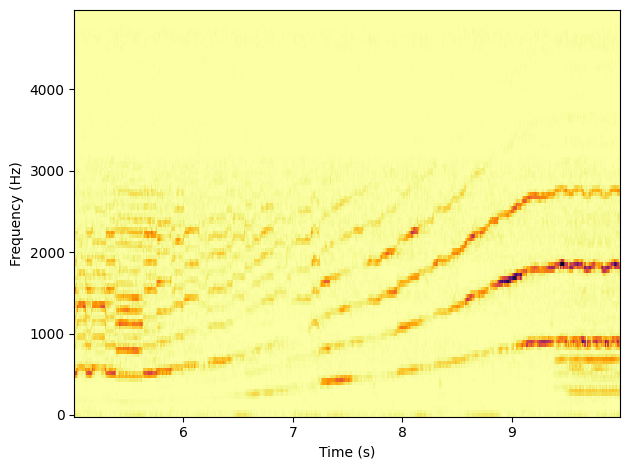

In [73]:
from thinkdsp import read_wave

download(
    "https://archive.org/download/rhapblue11924/rhapblue11924_vbr.mp3"
)

# 3. Convert MP3 to a format ThinkDSP can read:
#    -ac 1          means mono
#    -ar 11025      means 11,025 samples per second
#    -c:a pcm_s16le means standard 16-bit PCM WAV
!ffmpeg -y -i rhapblue11924_vbr.mp3 -ac 1 -ar 11025 -c:a pcm_s16le rhapsody.wav

wave = read_wave('rhapsody.wav')

wave.normalize()

segment = wave.segment(start=5, duration=5)
segment.make_audio()

spectog = segment.make_spectrogram(seg_length = 256)

spectog.plot(high=5000)

decorate(xlabel='Time (s)', ylabel = 'Frequency (Hz)')
# similar to a chirp so what would expect it to have the spectogram of a chirp, linear change of pitch epxonential frequency chanes


In [74]:
segment.make_audio()

#3.5

Assuming that the player moves the slide at a constant speed, how does frequency vary with time?
Write a class called TromboneGliss that extends Chirp and provides
evaluate. Make a wave that simulates a trombone glissando from C3 up
to F3 and back down to C3. C3 is 262 Hz; F3 is 349 Hz.
3.9. Plot a spectrogram of the resulting wave. Is a trombone glissando more like a linear or exponential chirp?


In [86]:
# what do you know the frequency is inverse proportional to the lenght,

class TromboneGliss(Chirp):
    def evaluate(self, ts):
       l1, l2 = 1/self.start, 1/self.end
       lengths = np.linspace(l1, l2, len(ts))

    #linearly interpolotaitng the relative lengths is exact same thing as intepolating the actual length just scaled by factor of C, and ebcasue way we define l1 and l2 take reciporcal to get the frequency
       freqs = 1/lengths
       dts = np.diff(ts, prepend=0)
       dphis = PI2 * freqs * dts

       phases = np.cumsum(dphis)

       ys = self.amp * np.cos(phases)
       return ys
        # return ys




In [87]:

tglissUp = TromboneGliss(349, 262)
tglissDown = TromboneGliss(262, 349)

wave1 = tglissUp.make_wave(duration=1)
wave1.apodize()
wave1.make_audio()

In [88]:

wave2 = tglissDown.make_wave(duration=1, framerate=11025)
wave2.apodize()
wave2.make_audio()

In [89]:
wave = wave1 | wave2

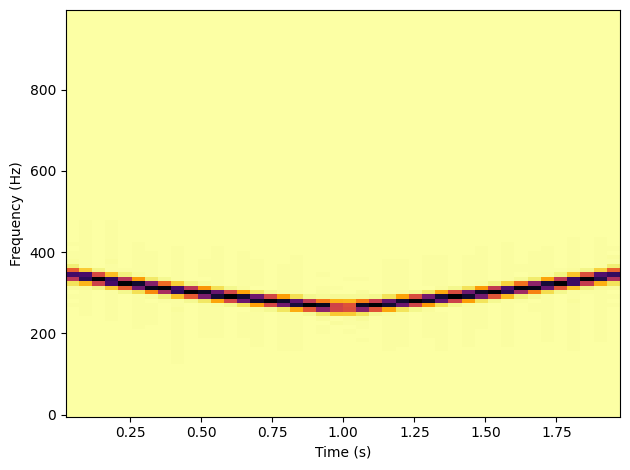

In [91]:
wave.make_audio()
specto = wave.make_spectrogram(1024)
specto.plot(high = 1000)
decorate(xlabel="Time (s)")
decorate(ylabel="Frequency (Hz)")

#3.6

Make or find a recording of a series of vowel sounds and look at
the spectrogram. Can you identify different vowels?


In [101]:
download("https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/soln/87778__marcgascon7__vocals.wav")

Downloaded 87778__marcgascon7__vocals.wav


In [102]:
wave = read_wave('87778__marcgascon7__vocals.wav')

wave.normalize()

wave.make_audio()

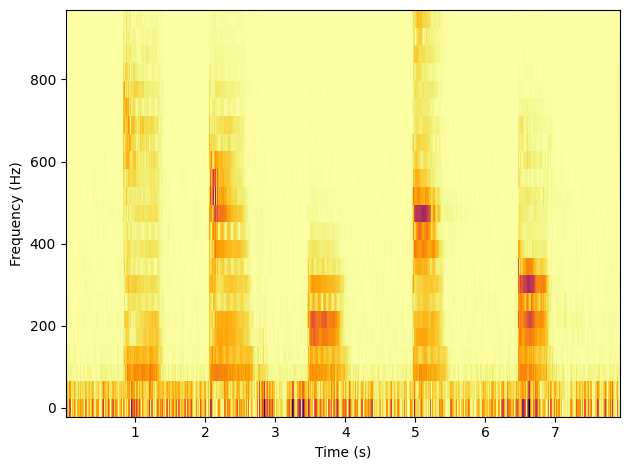

In [109]:
specto = wave.make_spectrogram(1024)
specto.plot(high = 1000)
decorate(xlabel='Time (s)')
decorate(ylabel='Frequency (Hz)')

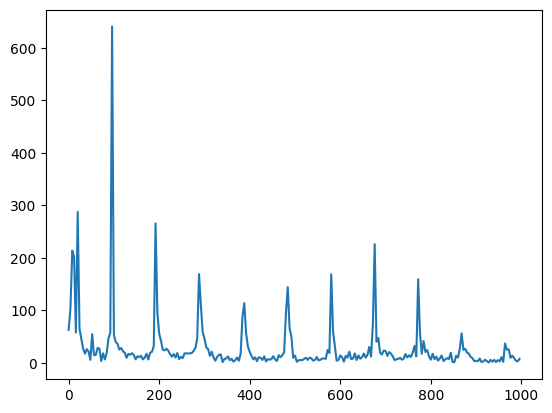

In [110]:
high = 1000

segment = wave.segment(start=1, duration=0.25)
segment.make_spectrum().plot(high=high)

Formants are the peaks that you see the ark bands that are higher up.
Spectogram and spectrum shows the formats (peaks taht aren't fundmanetal) as well as the fact that some vowels don't have any high frequency components.